# Phase 3 — Feature Engineering
### Early Disease Prediction Using Healthcare Data Warehouse

**Objectives of this notebook:**

1. Separate features (X) from target (y) for every dataset
2. Apply **stratified 80/20 train/test splits** (no data leakage)
3. **Encode** multi-category string columns in the stroke dataset (One-Hot)
4. **Scale** continuous features using StandardScaler fitted *only* on training data
5. Handle **class imbalance** — SMOTE for stroke, class weights for autism & diabetes
6. Compute quick **Random Forest feature importances** to guide modelling
7. **Persist all artifacts** (arrays + scalers + CV objects) to `models/saved/`

---
| Dataset | Split | CV Folds | Imbalance Strategy |
|---|---|---|---|
| Autism Screening | 80 / 20 | StratifiedKFold(5) | class_weight='balanced' |
| Diabetes Risk | 80 / 20 | StratifiedKFold(10) | class_weight='balanced' |
| Stroke Prediction | 80 / 20 | StratifiedKFold(5) | SMOTE + scale_pos_weight |

In [1]:
import os
import warnings
import joblib
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import seaborn as sns
from pathlib import Path

from sklearn.model_selection    import train_test_split, StratifiedKFold
from sklearn.preprocessing      import StandardScaler
from sklearn.ensemble           import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
    print("imbalanced-learn  : OK")
except ImportError:
    SMOTE_OK = False
    print("WARNING: imbalanced-learn not found.")
    print("  Install with: pip install imbalanced-learn")

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 110,
    'figure.facecolor': 'white',
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
})

# --- Paths ---
_cwd  = Path.cwd()
ROOT  = _cwd.parent if _cwd.name == 'models' else _cwd
CLEAN = ROOT / 'datasets' / 'cleaned'
SAVED = ROOT / 'models'   / 'saved'
FIGS  = ROOT / 'reports'  / 'figures'
SAVED.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True,  exist_ok=True)

RANDOM_STATE = 42

def savefig(fname):
    plt.savefig(FIGS / fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"  [SAVED] reports/figures/{fname}")

print(f"ROOT  : {ROOT}")
print(f"SAVED : {SAVED}")

imbalanced-learn  : OK
ROOT  : D:\NMU\Data Mining\datamining_project
SAVED : D:\NMU\Data Mining\datamining_project\models\saved


In [2]:
df_a = pd.read_csv(CLEAN / 'autism_cleaned.csv')
df_d = pd.read_csv(CLEAN / 'diabetes_cleaned.csv')
df_s = pd.read_csv(CLEAN / 'stroke_cleaned.csv')

print(f"{'Dataset':<22} {'Rows':>6} {'Cols':>5} {'Pos':>7} {'Neg':>7} {'Ratio':>8}")
print("-" * 60)
for name, df in [('Autism Screening', df_a),
                 ('Diabetes Risk',    df_d),
                 ('Stroke Prediction',df_s)]:
    pos   = (df['Class'] == 1).sum()
    neg   = (df['Class'] == 0).sum()
    ratio = neg / pos
    print(f"{name:<22} {len(df):>6,} {df.shape[1]:>5} "
          f"{pos:>7,} {neg:>7,} {ratio:>7.1f}:1")

Dataset                  Rows  Cols     Pos     Neg    Ratio
------------------------------------------------------------
Autism Screening        7,129    16   2,378   4,751     2.0:1
Diabetes Risk             520    17     332     188     0.6:1
Stroke Prediction       5,110    11     165   4,945    30.0:1


---
## 1 · Autism Screening — Feature Engineering

**Features used (15 total):**
- Behavioural: `A1` – `A10` (binary 0/1)
- Derived: `AQ_Score` = sum of A1–A10
- Demographic: `Age` (months), `Sex`, `Jaundice`, `Family_ASD`

**Continuous columns to scale:** `Age`, `AQ_Score`
(Tree models don't need scaling, but scaled versions are saved for LR baseline.)

**Imbalance:** 1 : 2.4 — mild. Strategy: `class_weight='balanced'`.
SMOTE is optional; we demonstrate it but use class weights by default.

In [3]:
# ── 1. X / y ────────────────────────────────────────────────────────────
FEATURE_COLS_A = [c for c in df_a.columns if c != 'Class']
X_a = df_a[FEATURE_COLS_A]
y_a = df_a['Class']

print(f"Autism  X shape : {X_a.shape}")
print(f"Autism  y shape : {y_a.shape}")
print(f"Features        : {FEATURE_COLS_A}")

# ── 2. Stratified 80 / 20 split ─────────────────────────────────────────
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.2, stratify=y_a, random_state=RANDOM_STATE)

print(f"\nTrain : {X_a_train.shape[0]:,}  "
      f"(pos={y_a_train.sum():,}, neg={(y_a_train==0).sum():,})")
print(f"Test  : {X_a_test.shape[0]:,}  "
      f"(pos={y_a_test.sum():,}, neg={(y_a_test==0).sum():,})")

# ── 3. Scale continuous features (fit on TRAIN only) ────────────────────
CONT_A = ['Age', 'AQ_Score']
scaler_a = StandardScaler()

X_a_train_sc = X_a_train.copy()
X_a_test_sc  = X_a_test.copy()
X_a_train_sc[CONT_A] = scaler_a.fit_transform(X_a_train[CONT_A])
X_a_test_sc[CONT_A]  = scaler_a.transform(X_a_test[CONT_A])

print(f"\nScaled columns  : {CONT_A}")
print(f"Scaler mean     : {dict(zip(CONT_A, scaler_a.mean_.round(2)))}")
print(f"Scaler std      : {dict(zip(CONT_A, scaler_a.scale_.round(2)))}")

# ── 4. Class weights ─────────────────────────────────────────────────────
cw_a     = compute_class_weight('balanced',
                                classes=np.array([0, 1]),
                                y=y_a_train.values)
cw_dict_a = {0: round(cw_a[0], 4), 1: round(cw_a[1], 4)}
print(f"\nClass weights   : {cw_dict_a}")
print(f"  => Class 1 gets {cw_a[1]/cw_a[0]:.2f}x more weight than Class 0")

# ── 5. StratifiedKFold CV ────────────────────────────────────────────────
cv_a = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"\nCV strategy     : StratifiedKFold(n_splits=5)")

Autism  X shape : (7129, 15)
Autism  y shape : (7129,)
Features        : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jaundice', 'Family_ASD', 'AQ_Score']

Train : 5,703  (pos=1,902, neg=3,801)
Test  : 1,426  (pos=476, neg=950)

Scaled columns  : ['Age', 'AQ_Score']
Scaler mean     : {'Age': 17.19, 'AQ_Score': 5.21}
Scaler std      : {'Age': 15.03, 'AQ_Score': 2.66}

Class weights   : {0: 0.7502, 1: 1.4992}
  => Class 1 gets 2.00x more weight than Class 0

CV strategy     : StratifiedKFold(n_splits=5)


In [4]:
autism_artifacts = {
    # Raw (unscaled) — for tree models
    'X_train'        : X_a_train.values,
    'X_test'         : X_a_test.values,
    # Scaled — for LR / SVM baselines
    'X_train_scaled' : X_a_train_sc.values,
    'X_test_scaled'  : X_a_test_sc.values,
    # Labels
    'y_train'        : y_a_train.values,
    'y_test'         : y_a_test.values,
    # Metadata
    'feature_names'  : FEATURE_COLS_A,
    'scaler'         : scaler_a,
    'cv'             : cv_a,
    'class_weight'   : cw_dict_a,
    'n_classes'      : 2,
    'pos_label'      : 1,
}

out_path = SAVED / 'autism_artifacts.pkl'
joblib.dump(autism_artifacts, out_path)
size_kb = out_path.stat().st_size / 1024
print(f"[SAVED] autism_artifacts.pkl  ({size_kb:.1f} KB)")
print(f"  Keys: {list(autism_artifacts.keys())}")

[SAVED] autism_artifacts.pkl  (1728.2 KB)
  Keys: ['X_train', 'X_test', 'X_train_scaled', 'X_test_scaled', 'y_train', 'y_test', 'feature_names', 'scaler', 'cv', 'class_weight', 'n_classes', 'pos_label']


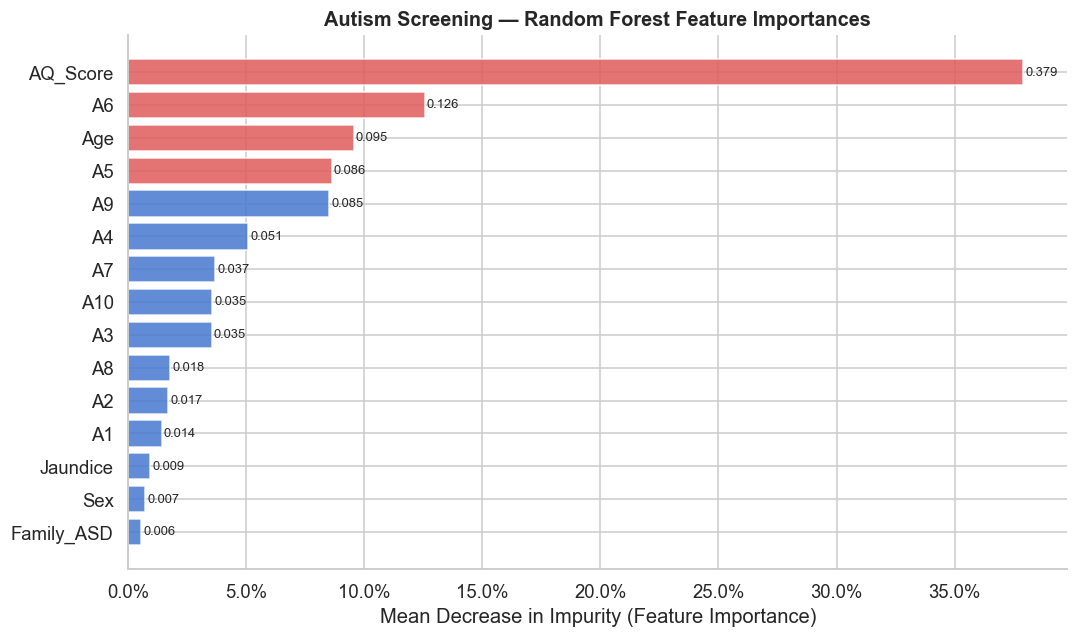

  [SAVED] reports/figures/15_autism_feature_importance.png

Top 5 features:
  AQ_Score         0.3789
  A6               0.1255
  Age              0.0954
  A5               0.0861
  A9               0.0851


In [5]:
rf_a = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_a.fit(X_a_train, y_a_train)

importances_a = pd.Series(rf_a.feature_importances_,
                           index=FEATURE_COLS_A).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#E05C5C' if imp >= importances_a.quantile(0.75) else '#4878CF'
           for imp in importances_a]
bars = ax.barh(importances_a.index, importances_a.values,
               color=colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Autism Screening — Random Forest Feature Importances')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}", va='center', fontsize=8.5)

plt.tight_layout()
savefig('15_autism_feature_importance.png')

print("\nTop 5 features:")
for feat, val in importances_a.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<15}  {val:.4f}")

---
## 2 · Diabetes Risk — Feature Engineering

**Features used (16 total):**
- Continuous: `Age`
- Binary: `Gender` + 14 symptom columns

**Continuous column to scale:** `Age` only

**Dataset size warning:** Only 520 rows → use **10-fold CV** to maximise
each validation fold's size and reduce variance in the evaluation.

**Imbalance:** 1 : 1.6 — mild. Strategy: `class_weight='balanced'`.

In [6]:
# ── 1. X / y ────────────────────────────────────────────────────────────
FEATURE_COLS_D = [c for c in df_d.columns if c != 'Class']
X_d = df_d[FEATURE_COLS_D]
y_d = df_d['Class']

print(f"Diabetes X shape : {X_d.shape}")
print(f"Features         : {FEATURE_COLS_D}")

# ── 2. Stratified 80 / 20 split ─────────────────────────────────────────
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, stratify=y_d, random_state=RANDOM_STATE)

print(f"\nTrain : {X_d_train.shape[0]:,}  "
      f"(pos={y_d_train.sum():,}, neg={(y_d_train==0).sum():,})")
print(f"Test  : {X_d_test.shape[0]:,}  "
      f"(pos={y_d_test.sum():,}, neg={(y_d_test==0).sum():,})")

# ── 3. Scale Age only ───────────────────────────────────────────────────
CONT_D   = ['Age']
scaler_d = StandardScaler()

X_d_train_sc = X_d_train.copy()
X_d_test_sc  = X_d_test.copy()
X_d_train_sc[CONT_D] = scaler_d.fit_transform(X_d_train[CONT_D])
X_d_test_sc[CONT_D]  = scaler_d.transform(X_d_test[CONT_D])

print(f"\nScaled column : Age")
print(f"  Mean (train): {scaler_d.mean_[0]:.2f}  "
      f"Std (train): {scaler_d.scale_[0]:.2f}")

# ── 4. Class weights ─────────────────────────────────────────────────────
cw_d      = compute_class_weight('balanced',
                                 classes=np.array([0, 1]),
                                 y=y_d_train.values)
cw_dict_d = {0: round(cw_d[0], 4), 1: round(cw_d[1], 4)}
print(f"\nClass weights : {cw_dict_d}")

# ── 5. 10-fold CV (small dataset) ────────────────────────────────────────
cv_d = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print("CV strategy   : StratifiedKFold(n_splits=10)  [small dataset]")

Diabetes X shape : (520, 16)
Features         : ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']

Train : 416  (pos=266, neg=150)
Test  : 104  (pos=66, neg=38)

Scaled column : Age
  Mean (train): 48.27  Std (train): 12.04

Class weights : {0: 1.3867, 1: 0.782}
CV strategy   : StratifiedKFold(n_splits=10)  [small dataset]


In [7]:
diabetes_artifacts = {
    'X_train'        : X_d_train.values,
    'X_test'         : X_d_test.values,
    'X_train_scaled' : X_d_train_sc.values,
    'X_test_scaled'  : X_d_test_sc.values,
    'y_train'        : y_d_train.values,
    'y_test'         : y_d_test.values,
    'feature_names'  : FEATURE_COLS_D,
    'scaler'         : scaler_d,
    'cv'             : cv_d,
    'class_weight'   : cw_dict_d,
    'n_classes'      : 2,
    'pos_label'      : 1,
}

out_path = SAVED / 'diabetes_artifacts.pkl'
joblib.dump(diabetes_artifacts, out_path)
size_kb  = out_path.stat().st_size / 1024
print(f"[SAVED] diabetes_artifacts.pkl  ({size_kb:.1f} KB)")

[SAVED] diabetes_artifacts.pkl  (135.8 KB)


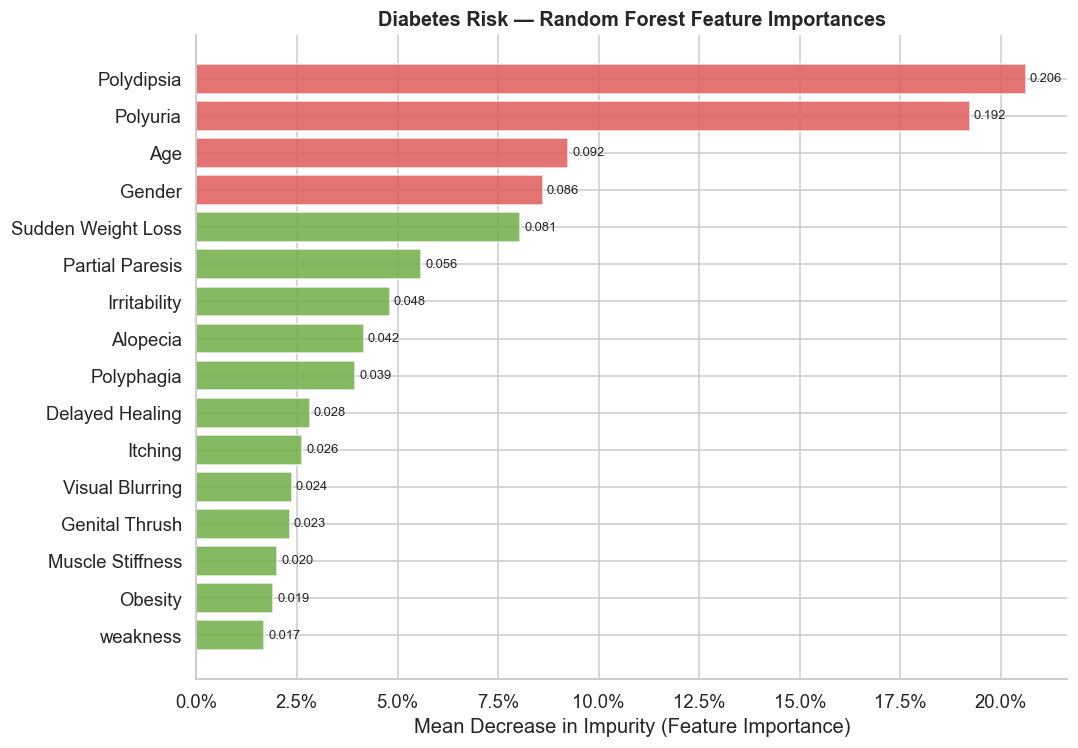

  [SAVED] reports/figures/16_diabetes_feature_importance.png

Top 5 features:
  Polydipsia                 0.2062
  Polyuria                   0.1922
  Age                        0.0924
  Gender                     0.0861
  Sudden Weight Loss         0.0805


In [8]:
rf_d = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_d.fit(X_d_train, y_d_train)

importances_d = pd.Series(rf_d.feature_importances_,
                           index=FEATURE_COLS_D).sort_values(ascending=True)
pretty = {
    'sudden weight loss': 'Sudden Weight Loss',
    'Genital thrush'    : 'Genital Thrush',
    'visual blurring'   : 'Visual Blurring',
    'delayed healing'   : 'Delayed Healing',
    'partial paresis'   : 'Partial Paresis',
    'muscle stiffness'  : 'Muscle Stiffness',
}
clean_labels = [pretty.get(f, f) for f in importances_d.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#E05C5C' if imp >= importances_d.quantile(0.75) else '#70AD47'
           for imp in importances_d]
bars = ax.barh(clean_labels, importances_d.values,
               color=colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Diabetes Risk — Random Forest Feature Importances')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}", va='center', fontsize=8.5)
plt.tight_layout()
savefig('16_diabetes_feature_importance.png')

print("\nTop 5 features:")
for feat, val in importances_d.sort_values(ascending=False).head(5).items():
    print(f"  {pretty.get(feat, feat):<25}  {val:.4f}")

---
## 3 · Stroke Prediction — Feature Engineering

**Three sub-steps required before splitting:**

### 3A — One-Hot Encoding
Two string columns need to be encoded:
- `work_type` (5 categories) → 4 dummy columns (`drop_first=True`)
- `smoking_status` (4 categories) → 3 dummy columns

### 3B — Scaling
Three continuous columns: `age`, `avg_glucose_level`, `bmi`
Scaler fitted on **training data only**.

### 3C — SMOTE  *(on training fold only — never on test data)*
Ratio 19.5 : 1 is too severe for class weights alone.
SMOTE generates **synthetic minority samples** by interpolating between
existing stroke records in feature space.

> **Critical rule:** SMOTE is applied *after* the train/test split.
> The test set remains untouched to give an honest evaluation.

In [9]:
# ── One-Hot Encode work_type & smoking_status ────────────────────────────
print("Columns before encoding:", df_s.columns.tolist())
print(f"  work_type categories   : {sorted(df_s['work_type'].unique())}")
print(f"  smoking_status cats    : {sorted(df_s['smoking_status'].unique())}")

df_s_enc = pd.get_dummies(
    df_s,
    columns=['work_type', 'smoking_status'],
    drop_first=True,   # drops alphabetically first category per column
    dtype=int,
)

# Verify
new_cols = [c for c in df_s_enc.columns if c not in df_s.columns]
print(f"\nNew dummy columns ({len(new_cols)}): {new_cols}")
print(f"\nColumns after encoding ({df_s_enc.shape[1]} total):")
print(df_s_enc.columns.tolist())

Columns before encoding: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'Class']
  work_type categories   : ['Children', 'Govt_job', 'Never_Worked', 'Private', 'Self-Employed']
  smoking_status cats    : ['Unknown', 'formerly smoked', 'never smoked', 'smokes']

New dummy columns (7): ['work_type_Govt_job', 'work_type_Never_Worked', 'work_type_Private', 'work_type_Self-Employed', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

Columns after encoding (16 total):
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'Class', 'work_type_Govt_job', 'work_type_Never_Worked', 'work_type_Private', 'work_type_Self-Employed', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [10]:
# ── 1. X / y ────────────────────────────────────────────────────────────
FEATURE_COLS_S = [c for c in df_s_enc.columns if c != 'Class']
X_s = df_s_enc[FEATURE_COLS_S]
y_s = df_s_enc['Class']

print(f"Stroke X shape : {X_s.shape}  ({len(FEATURE_COLS_S)} features)")

# ── 2. Stratified 80 / 20 split ─────────────────────────────────────────
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_s, y_s, test_size=0.2, stratify=y_s, random_state=RANDOM_STATE)

print(f"\nTrain : {X_s_train.shape[0]:,}  "
      f"(pos={y_s_train.sum():,}, neg={(y_s_train==0).sum():,})")
print(f"Test  : {X_s_test.shape[0]:,}  "
      f"(pos={y_s_test.sum():,}, neg={(y_s_test==0).sum():,})")

# Verify stratification preserved ratio
train_ratio = (y_s_train == 0).sum() / y_s_train.sum()
test_ratio  = (y_s_test  == 0).sum() / y_s_test.sum()
print(f"\nImbalance ratio — Train : {train_ratio:.1f}:1  |  Test : {test_ratio:.1f}:1")
print("  => Stratification maintained correctly." if abs(train_ratio - test_ratio) < 1
      else "  => WARNING: ratio mismatch — check stratify= argument")

# ── 3. Scale continuous features ────────────────────────────────────────
CONT_S   = ['age', 'avg_glucose_level', 'bmi']
scaler_s = StandardScaler()

X_s_train_sc = X_s_train.copy()
X_s_test_sc  = X_s_test.copy()
X_s_train_sc[CONT_S] = scaler_s.fit_transform(X_s_train[CONT_S])
X_s_test_sc[CONT_S]  = scaler_s.transform(X_s_test[CONT_S])

print(f"\nScaled columns : {CONT_S}")
for col, mean, std in zip(CONT_S, scaler_s.mean_, scaler_s.scale_):
    print(f"  {col:<22} mean={mean:.2f}  std={std:.2f}")

# ── 4. scale_pos_weight for XGBoost ─────────────────────────────────────
n_neg  = (y_s_train == 0).sum()
n_pos  = (y_s_train == 1).sum()
spw    = round(n_neg / n_pos, 2)
print(f"\nXGBoost scale_pos_weight = {n_neg}/{n_pos} = {spw}")

Stroke X shape : (5110, 15)  (15 features)

Train : 4,088  (pos=132, neg=3,956)
Test  : 1,022  (pos=33, neg=989)

Imbalance ratio — Train : 30.0:1  |  Test : 30.0:1
  => Stratification maintained correctly.

Scaled columns : ['age', 'avg_glucose_level', 'bmi']
  age                    mean=43.24  std=22.69
  avg_glucose_level      mean=106.26  std=45.22
  bmi                    mean=28.66  std=7.11

XGBoost scale_pos_weight = 3956/132 = 29.97


In [11]:
if not SMOTE_OK:
    print("SMOTE unavailable — install imbalanced-learn to run this cell.")
else:
    # ── Apply SMOTE to TRAINING data only ────────────────────────────────
    # Using scaled version (SMOTE interpolates in feature space;
    # scaled features give equal weight to all dimensions)
    smote = SMOTE(
        sampling_strategy='minority',  # oversample minority to match majority
        k_neighbors=5,
        random_state=RANDOM_STATE,
    )

    X_s_train_smote, y_s_train_smote = smote.fit_resample(
        X_s_train_sc.values, y_s_train.values)

    # Also generate unscaled SMOTE version for tree-based models
    smote_raw = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)
    X_s_train_smote_raw, y_s_train_smote_raw = smote_raw.fit_resample(
        X_s_train.values, y_s_train.values)

    print("SMOTE applied to training set (scaled):")
    print(f"  Before: {X_s_train_sc.shape[0]:,} samples  "
          f"(pos={y_s_train.sum():,}, neg={(y_s_train==0).sum():,})")
    print(f"  After : {X_s_train_smote.shape[0]:,} samples  "
          f"(pos={y_s_train_smote.sum():,}, "
          f"neg={(y_s_train_smote==0).sum():,})")
    print(f"  New ratio: 1 : {(y_s_train_smote==0).sum()/y_s_train_smote.sum():.1f}")
    print(f"\n  Test set : {X_s_test.shape[0]:,} samples — UNCHANGED (no leakage)")

SMOTE applied to training set (scaled):
  Before: 4,088 samples  (pos=132, neg=3,956)
  After : 7,912 samples  (pos=3,956, neg=3,956)
  New ratio: 1 : 1.0

  Test set : 1,022 samples — UNCHANGED (no leakage)


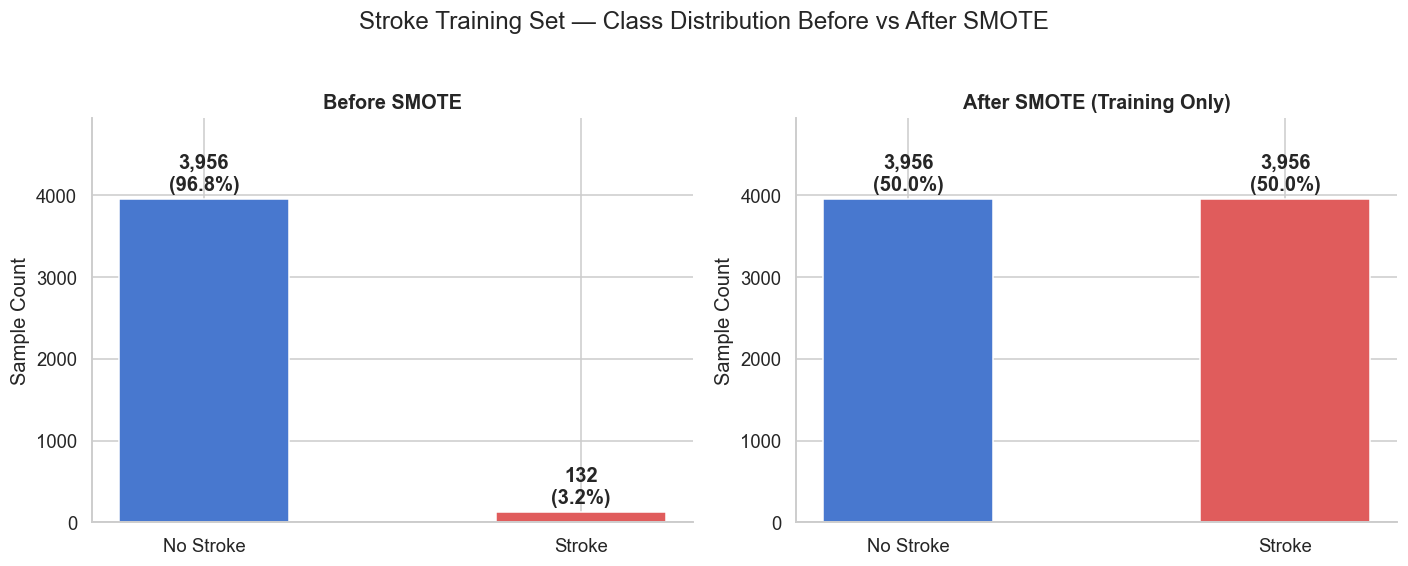

  [SAVED] reports/figures/17_stroke_smote_before_after.png


In [12]:
if not SMOTE_OK:
    print("SMOTE unavailable — skipping visualisation.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Stroke Training Set — Class Distribution Before vs After SMOTE',
                 y=1.03)

    # Before
    vals_before  = [int((y_s_train == 0).sum()), int(y_s_train.sum())]
    bars0 = axes[0].bar(['No Stroke', 'Stroke'], vals_before,
                         color=['#4878CF', '#E05C5C'],
                         edgecolor='white', width=0.45)
    axes[0].set_title('Before SMOTE')
    axes[0].set_ylabel('Sample Count')
    axes[0].spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars0, vals_before):
        pct = val / sum(vals_before) * 100
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 50,
                     f"{val:,}\n({pct:.1f}%)",
                     ha='center', va='bottom', fontweight='bold')
    axes[0].set_ylim(0, max(vals_before) * 1.25)

    # After
    vals_after = [int((y_s_train_smote == 0).sum()),
                  int(y_s_train_smote.sum())]
    bars1 = axes[1].bar(['No Stroke', 'Stroke'], vals_after,
                         color=['#4878CF', '#E05C5C'],
                         edgecolor='white', width=0.45)
    axes[1].set_title('After SMOTE (Training Only)')
    axes[1].set_ylabel('Sample Count')
    axes[1].spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars1, vals_after):
        pct = val / sum(vals_after) * 100
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 50,
                     f"{val:,}\n({pct:.1f}%)",
                     ha='center', va='bottom', fontweight='bold')
    axes[1].set_ylim(0, max(vals_after) * 1.25)

    plt.tight_layout()
    savefig('17_stroke_smote_before_after.png')

In [13]:
stroke_artifacts = {
    # Raw (unscaled, no SMOTE) — for tree models
    'X_train'              : X_s_train.values,
    'X_test'               : X_s_test.values,
    # Scaled (no SMOTE) — for LR baseline
    'X_train_scaled'       : X_s_train_sc.values,
    'X_test_scaled'        : X_s_test_sc.values,
    # Labels (original split)
    'y_train'              : y_s_train.values,
    'y_test'               : y_s_test.values,
    # Metadata
    'feature_names'        : FEATURE_COLS_S,
    'scaler'               : scaler_s,
    'cv'                   : StratifiedKFold(n_splits=5, shuffle=True,
                                             random_state=RANDOM_STATE),
    'scale_pos_weight'     : spw,
    'n_classes'            : 2,
    'pos_label'            : 1,
}

# Add SMOTE arrays if available
if SMOTE_OK:
    stroke_artifacts.update({
        'X_train_smote'        : X_s_train_smote,
        'y_train_smote'        : y_s_train_smote,
        'X_train_smote_raw'    : X_s_train_smote_raw,
        'y_train_smote_raw'    : y_s_train_smote_raw,
    })

out_path = SAVED / 'stroke_artifacts.pkl'
joblib.dump(stroke_artifacts, out_path)
size_kb  = out_path.stat().st_size / 1024
print(f"[SAVED] stroke_artifacts.pkl  ({size_kb:.1f} KB)")
print(f"  Keys: {list(stroke_artifacts.keys())}")

[SAVED] stroke_artifacts.pkl  (3217.7 KB)
  Keys: ['X_train', 'X_test', 'X_train_scaled', 'X_test_scaled', 'y_train', 'y_test', 'feature_names', 'scaler', 'cv', 'scale_pos_weight', 'n_classes', 'pos_label', 'X_train_smote', 'y_train_smote', 'X_train_smote_raw', 'y_train_smote_raw']


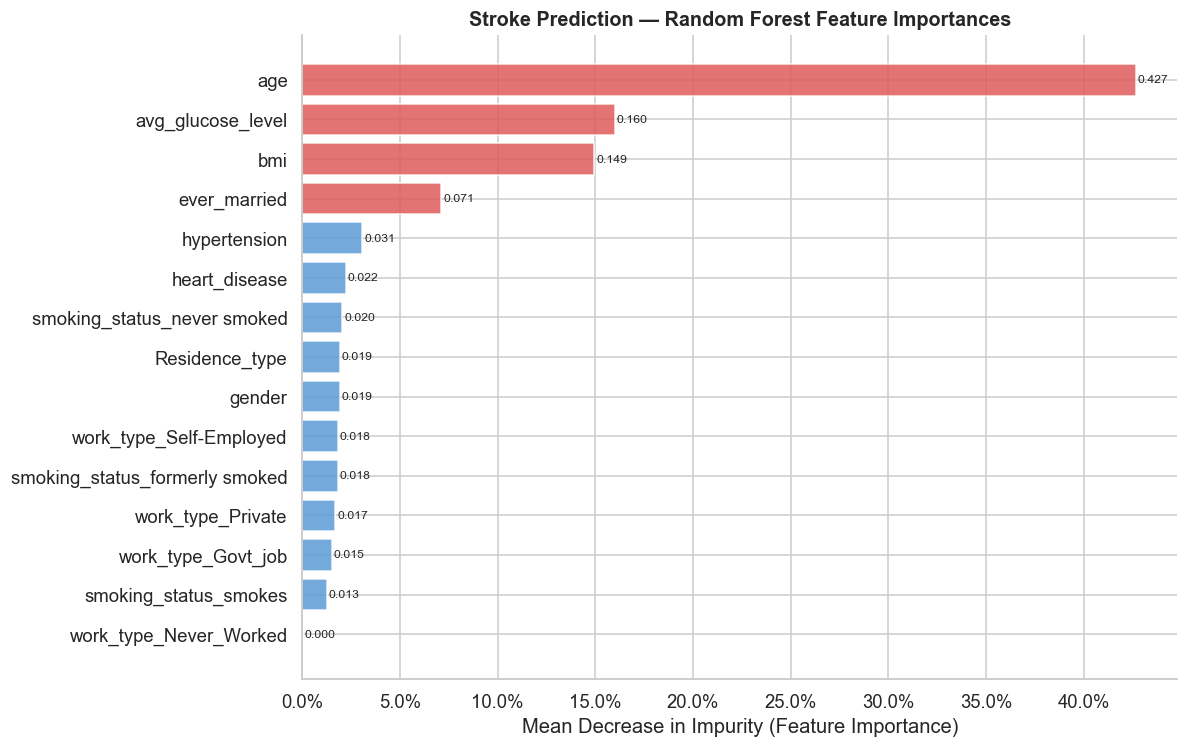

  [SAVED] reports/figures/18_stroke_feature_importance.png

Top 7 features:
  age                                       0.4266
  avg_glucose_level                         0.1599
  bmi                                       0.1494
  ever_married                              0.0712
  hypertension                              0.0308
  heart_disease                             0.0223
  smoking_status_never smoked               0.0204


In [14]:
# Train on raw (unscaled) training data — trees don't need scaling
rf_s = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_s.fit(X_s_train, y_s_train)

importances_s = pd.Series(rf_s.feature_importances_,
                           index=FEATURE_COLS_S).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors  = ['#E05C5C' if imp >= importances_s.quantile(0.75) else '#5B9BD5'
           for imp in importances_s]
bars = ax.barh(importances_s.index, importances_s.values,
               color=colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Stroke Prediction — Random Forest Feature Importances')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}", va='center', fontsize=8)
plt.tight_layout()
savefig('18_stroke_feature_importance.png')

print("\nTop 7 features:")
for feat, val in importances_s.sort_values(ascending=False).head(7).items():
    print(f"  {feat:<40}  {val:.4f}")

---
## 4 · Cross-Dataset Feature Distribution Check

A quick sanity check: do the scaled training and test sets have similar
distributions? Large shifts indicate either a bad split or a data
ordering artefact — both would cause unreliable evaluation.

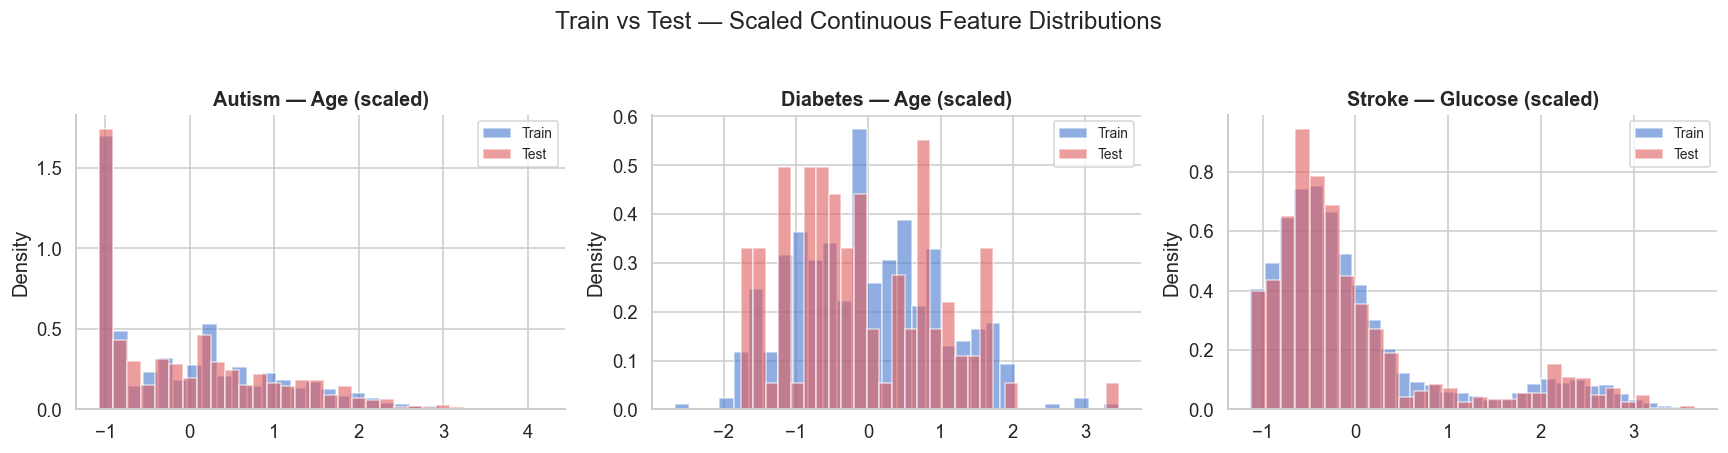

  [SAVED] reports/figures/19_train_test_distribution_check.png
Distribution check summary (KS test — p > 0.05 = no significant shift):
  Autism — Age (scaled)                     KS=0.0180  p=0.8440  [OK]
  Diabetes — Age (scaled)                   KS=0.1130  p=0.2284  [OK]
  Stroke — Glucose (scaled)                 KS=0.0364  p=0.2242  [OK]


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Train vs Test — Scaled Continuous Feature Distributions',
             y=1.03)

checks = [
    (X_a_train_sc['Age'],            X_a_test_sc['Age'],
     'Autism — Age (scaled)'),
    (X_d_train_sc['Age'],            X_d_test_sc['Age'],
     'Diabetes — Age (scaled)'),
    (X_s_train_sc['avg_glucose_level'], X_s_test_sc['avg_glucose_level'],
     'Stroke — Glucose (scaled)'),
]

for ax, (train_col, test_col, title) in zip(axes, checks):
    ax.hist(train_col, bins=30, alpha=0.6, color='#4878CF',
            label='Train', density=True, edgecolor='white')
    ax.hist(test_col,  bins=30, alpha=0.6, color='#E05C5C',
            label='Test',  density=True, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
savefig('19_train_test_distribution_check.png')

print("Distribution check summary (KS test — p > 0.05 = no significant shift):")
from scipy import stats
for train_col, test_col, title in checks:
    ks_stat, ks_p = stats.ks_2samp(train_col.values, test_col.values)
    status = "OK" if ks_p > 0.05 else "WARNING"
    print(f"  {title:<40}  KS={ks_stat:.4f}  p={ks_p:.4f}  [{status}]")

---
## 5 · Summary & Artifact Inventory

All preprocessing artifacts have been saved to `models/saved/`.
Phase 4 (model training) will load these directly — no re-running needed.

In [16]:
summary = pd.DataFrame([
    dict(
        Dataset          = 'Autism Screening',
        Train_Rows       = X_a_train.shape[0],
        Test_Rows        = X_a_test.shape[0],
        Features         = X_a_train.shape[1],
        Scaled_Cols      = 'Age, AQ_Score',
        Encoded_Cols     = 'None needed',
        Imbalance_Fix    = 'class_weight=balanced',
        CV_Folds         = 5,
        Artifact_File    = 'autism_artifacts.pkl',
    ),
    dict(
        Dataset          = 'Diabetes Risk',
        Train_Rows       = X_d_train.shape[0],
        Test_Rows        = X_d_test.shape[0],
        Features         = X_d_train.shape[1],
        Scaled_Cols      = 'Age',
        Encoded_Cols     = 'None needed',
        Imbalance_Fix    = 'class_weight=balanced',
        CV_Folds         = 10,
        Artifact_File    = 'diabetes_artifacts.pkl',
    ),
    dict(
        Dataset          = 'Stroke Prediction',
        Train_Rows       = X_s_train.shape[0],
        Test_Rows        = X_s_test.shape[0],
        Features         = X_s_train.shape[1],
        Scaled_Cols      = 'age, avg_glucose, bmi',
        Encoded_Cols     = 'work_type, smoking_status',
        Imbalance_Fix    = f'SMOTE + scale_pos_weight={spw}',
        CV_Folds         = 5,
        Artifact_File    = 'stroke_artifacts.pkl',
    ),
]).set_index('Dataset')

pd.set_option('display.max_colwidth', 35)
summary

,Train_Rows,Test_Rows,Features,Scaled_Cols,Encoded_Cols,Imbalance_Fix,CV_Folds,Artifact_File
Dataset,,,,,,,,
Autism Screening,5703,1426,15,"Age, AQ_Score",None needed,class_weight=balanced,5,autism_artifacts.pkl
Diabetes Risk,416,104,16,Age,None needed,class_weight=balanced,10,diabetes_artifacts.pkl
Stroke Prediction,4088,1022,15,"age, avg_glucose, bmi","work_type, smoking_status",SMOTE + scale_pos_weight=29.97,5,stroke_artifacts.pkl


In [17]:
import glob

saved_files = sorted(glob.glob(str(SAVED / '*.pkl')))
fig_files   = sorted(glob.glob(str(FIGS  / '*.png')))

print(f"Saved artifacts ({len(saved_files)} files):")
for f in saved_files:
    kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<35}  {kb:>7.1f} KB")

print(f"\nNew figures ({len([f for f in fig_files if '15_' <= os.path.basename(f) <= '19z'])} this phase):")
for f in fig_files:
    name = os.path.basename(f)
    if name[:2] in ('15','16','17','18','19'):
        kb = os.path.getsize(f) / 1024
        print(f"  {name:<46}  {kb:>6.1f} KB")

print()
print("Phase 3 — Feature Engineering  COMPLETE")
print("Next: models/04_modeling.ipynb  ->  Train & evaluate all classifiers")

Saved artifacts (15 files):
  autism_artifacts.pkl                  1728.2 KB
  autism_best_model.pkl                    2.0 KB
  autism_ensemble_model.pkl             2131.9 KB
  autism_explainability.pkl                1.1 KB
  autism_ga_history.pkl                    1.8 KB
  diabetes_artifacts.pkl                 135.8 KB
  diabetes_best_model.pkl                527.1 KB
  diabetes_ensemble_model.pkl           1252.3 KB
  diabetes_explainability.pkl              1.3 KB
  diabetes_ga_history.pkl                  2.0 KB
  stroke_artifacts.pkl                  3217.7 KB
  stroke_best_model.pkl                    1.0 KB
  stroke_ensemble_model.pkl            10712.9 KB
  stroke_explainability.pkl                1.4 KB
  stroke_ga_history.pkl                    2.0 KB

New figures (5 this phase):
  15_autism_feature_importance.png                  83.0 KB
  16_diabetes_feature_importance.png               114.2 KB
  17_stroke_smote_before_after.png                  64.1 KB
  18_stroke_f